# Homework 5: Breast Cancer Classification Using Support Vector Machines

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Split: 70% train, 15% validation, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"Training samples:   {X_train.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")
print(f"Test samples:       {X_test.shape[0]}")

Training samples:   398
Validation samples: 85
Test samples:       86


## 1. Data Preprocessing and Exploration

Number of features: 30
Training samples:   398
Validation samples: 85
Test samples:       86


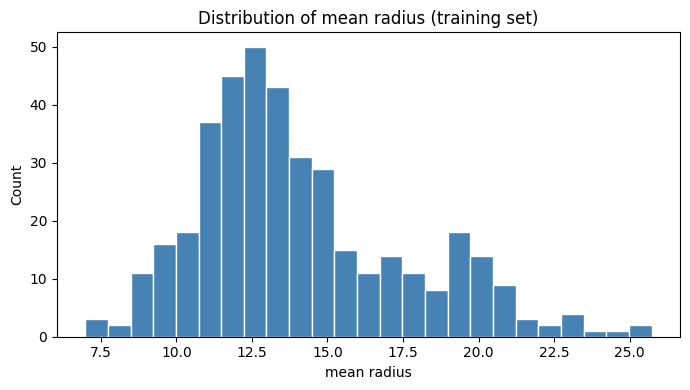

In [ ]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print(f"Number of features: {X_train.shape[1]}")
print(f"Training samples:   {X_train.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")
print(f"Test samples:       {X_test.shape[0]}")

# Histogram of mean radius (feature index 0)
feature_idx = 0
feature_name = data.feature_names[feature_idx]

plt.figure(figsize=(7, 4))
plt.hist(X_train[:, feature_idx], bins=25, color='steelblue', edgecolor='white')
plt.xlabel(feature_name)
plt.ylabel('Count')
plt.title(f'Distribution of {feature_name} (training set)')
plt.tight_layout()
plt.show()

**Question: Explain why feature scaling is particularly important for SVMs.**

SVMs find the hyperplane that maximizes the margin between the classes, and the margin is Euclidean distance. Suppose one feature ranges from 1 to 1000 and the other between 0 and 1. In that case, the feature with the higher range dominates the distance calculation and essentially ignores the other feature. By standardizing all features to have zero mean and unit variance, all features will equally contribute to determining the margin, and the optimization process will converge without numerical issues.


## 2. Linear Support Vector Machine

C= 0.01: val accuracy = 0.9765
C=  0.1: val accuracy = 0.9882
C=    1: val accuracy = 0.9882
C=   10: val accuracy = 0.9882


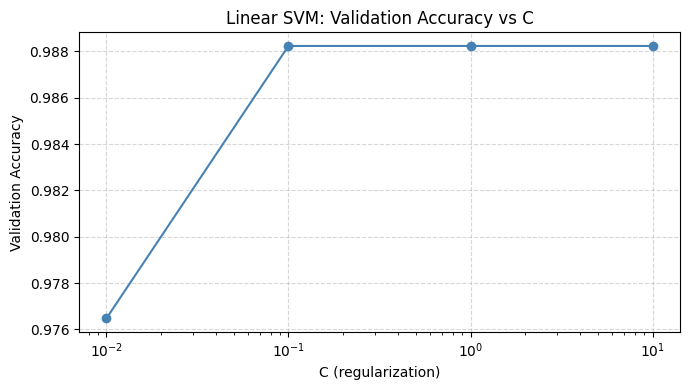

In [ ]:
C_values = [0.01, 0.1, 1, 10]
val_accuracies = []

for C in C_values:
    model = SVC(kernel='linear', C=C, random_state=42)
    model.fit(X_train_sc, y_train)
    acc = accuracy_score(y_val, model.predict(X_val_sc))
    val_accuracies.append(acc)
    print(f"C={C:5}: val accuracy = {acc:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(C_values, val_accuracies, marker='o', color='steelblue')
plt.xscale('log')
plt.xlabel('C (regularization)')
plt.ylabel('Validation Accuracy')
plt.title('Linear SVM: Validation Accuracy vs C')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Question: Describe how changing C affects model behavior in terms of underfitting and overfitting.**

C is the penalty that is assigned to each misclassified training point. If C is very small, such as 0.01, then there will be a lot of violations of the margin assigned to the training points; the model will underfit the training data. If C is very large, the model will overfit the training data; it will essentially memorize the training points but fail to generalize from those memorized points. The validation curve will display an improvement in model performance as C increases, but the improvement will plateau and possibly drop if C is too large to be optimal for the given training data.

## 3. Non-Linear SVM with RBF Kernel

In [ ]:
C_range     = [0.1, 1, 10]
gamma_range = [0.001, 0.01, 0.1]

best_acc   = 0
best_C     = None
best_gamma = None
results    = {}

for C in C_range:
    for gamma in gamma_range:
        model = SVC(kernel='rbf', C=C, gamma=gamma, random_state=42)
        model.fit(X_train_sc, y_train)
        acc = accuracy_score(y_val, model.predict(X_val_sc))
        results[(C, gamma)] = acc
        print(f"C={C:4}, gamma={gamma}: val accuracy = {acc:.4f}")
        if acc > best_acc:
            best_acc, best_C, best_gamma = acc, C, gamma

print(f"\nBest combination: C={best_C}, gamma={best_gamma}, accuracy={best_acc:.4f}")

C= 0.1, gamma=0.001: val accuracy = 0.7412
C= 0.1, gamma=0.01: val accuracy = 0.9647
C= 0.1, gamma=0.1: val accuracy = 0.9647
C=   1, gamma=0.001: val accuracy = 0.9647
C=   1, gamma=0.01: val accuracy = 0.9765
C=   1, gamma=0.1: val accuracy = 0.9647
C=  10, gamma=0.001: val accuracy = 0.9882
C=  10, gamma=0.01: val accuracy = 0.9765
C=  10, gamma=0.1: val accuracy = 0.9765

Best combination: C=10, gamma=0.001, accuracy=0.9882


**Question: Explain how the parameter γ influences the shape of the decision boundary.**

γ controls how far the influence of a single training point reaches. A small γ means each point has a wide reach; the model sees all the points as if they have a large neighborhood around them. Using a large γ means each training point’s influence is limited to a small area. The model begins to focus on the training points very closely around each instance. This creates a jagged decision boundary that overfits the training data. A small γ leads to underfitting, and a large γ leads to overfitting. Finding the correct value for both γ and C is necessary.

## 4. Final Evaluation on the Test Set

Accuracy:  0.9535
Precision: 0.9310
Recall:    1.0000
F1 Score:  0.9643

Confusion Matrix:
[[28  4]
 [ 0 54]]


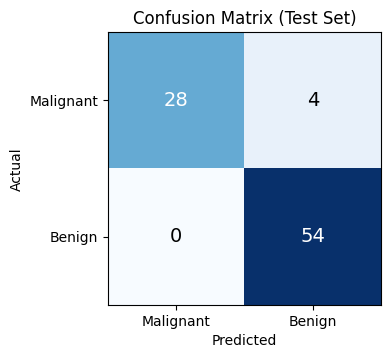

In [ ]:
final_model = SVC(kernel='rbf', C=best_C, gamma=best_gamma, random_state=42)
final_model.fit(X_train_sc, y_train)
y_pred = final_model.predict(X_test_sc)

acc  = accuracy_score(y_test, y_pred)
cm   = confusion_matrix(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"\nConfusion Matrix:\n{cm}")

fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Malignant', 'Benign'])
ax.set_yticklabels(['Malignant', 'Benign'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix (Test Set)')
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=14,
                color='white' if cm[i, j] > cm.max() / 2 else 'black')
plt.tight_layout()
plt.show()

## 5. Decision Boundary Visualization

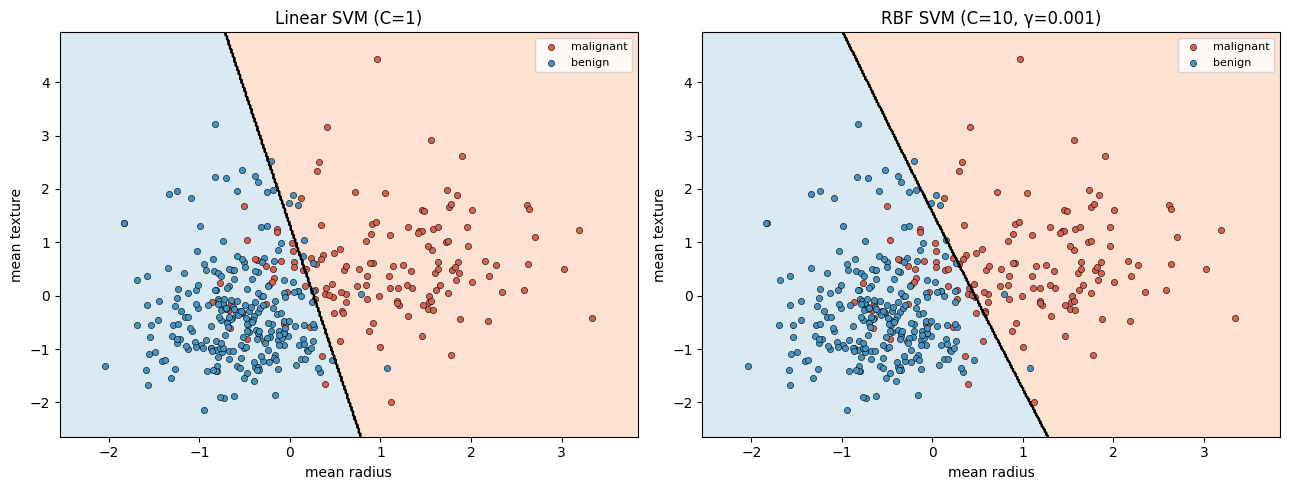

In [ ]:
# Use mean radius (0) and mean texture (1) for 2D visualization
f1_idx, f2_idx = 0, 1
f1_name = data.feature_names[f1_idx]
f2_name = data.feature_names[f2_idx]

X_train_2d = X_train_sc[:, [f1_idx, f2_idx]]
X_val_2d   = X_val_sc[:,   [f1_idx, f2_idx]]

svm_linear = SVC(kernel='linear', C=1, random_state=42)
svm_rbf    = SVC(kernel='rbf',    C=best_C, gamma=best_gamma, random_state=42)
svm_linear.fit(X_train_2d, y_train)
svm_rbf.fit(X_train_2d, y_train)

x_min = X_train_2d[:, 0].min() - 0.5
x_max = X_train_2d[:, 0].max() + 0.5
y_min = X_train_2d[:, 1].min() - 0.5
y_max = X_train_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                      np.linspace(y_min, y_max, 400))
grid = np.c_[xx.ravel(), yy.ravel()]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
models = [(svm_linear, 'Linear SVM (C=1)'), (svm_rbf, f'RBF SVM (C={best_C}, γ={best_gamma})')]
colors = ['#d6604d', '#4393c3']
cmap   = mcolors.ListedColormap(['#fddbc7', '#d1e5f0'])

for ax, (model, title) in zip(axes, models):
    Z = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=cmap, alpha=0.8)
    ax.contour(xx, yy, Z, colors='k', linewidths=0.8)
    for cls, color, label in zip([0, 1], colors, data.target_names):
        mask = y_train == cls
        ax.scatter(X_train_2d[mask, 0], X_train_2d[mask, 1],
                   c=color, edgecolors='k', linewidths=0.4, s=20, label=label)
    ax.set_xlabel(f1_name); ax.set_ylabel(f2_name)
    ax.set_title(title); ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

**Question: Compare the geometric differences between the linear and RBF decision boundaries.**

The linear SVM only finds one straight line (in 2D) that separates the two classes. The position of the data relative to this line does not matter; the SVM is limited to finding this one linear boundary, which might result in misclassifying some of the instances. The RBF SVM can find a boundary that bends and curves to allow for the SVM to find the best boundary for the training data instances. The RBF boundary might be overly complex relative to the training data, however, while the linear boundary is simpler and more robust to noise if the classes are linearly separable.

## 6. Critical Thinking Question

**1. Which model is likely to generalize better to unseen data?**

Model B is more likely to generalize well because it has fewer support vectors. Fewer support vectors indicate that there are fewer points close to the separating hyperplane - which indicates that the margin is wider and contains less noise.

**2. What does the number of support vectors indicate about the margin and model complexity?**

Fewer support vectors mean a larger margin - most of the training examples are further away from the decision boundary. A large number of support vectors means a smaller margin and more complex model.

**3. How might this relate to overfitting?**

When a model employs many support vectors, it means that it is attempting to model the training distribution quite closely, accounting for many of the edge cases and points that are noisy within the data. This can, however, lead to overfitting the model is essentially memorizing the noise of the training set rather than the underlying trend in the data. Model A’s use of many support vectors indicates that it is attempting to learn every training point correctly, at the cost of reduced confidence in its predictions. If Model A displays a high degree of accuracy on the training data but with significantly reduced accuracy on the test data relative to Model B, then the model is likely overfitting to the training data.